<a href="https://colab.research.google.com/github/aahan-charak24/Deep-Learning-Mastery/blob/main/MLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2>Maximum Likelihood Estimation </h2>



In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

<h3>Here, instead of outputting just single y we output a distribution. The distribution parameter defines a distribution the predicted y belongs to. Here we want to maximize the probability that given an input x or distribution parameter $\theta$ we get the correct y. More information is in the notes i added on github.</h3>

<h1> 1> Regression Problem</h1>


<h3>For mean squared loss, the loss function is optimizable if we focus only minimizing true-predicted square, so same loss function after mle in univariate regression or multivariate</h3>

In [3]:
np.random.seed(0)

In [6]:
def create_regression_dataset(n):
  X = np.random.randn(n, 2)
  noise = np.random.normal(0, 0.1, n)
  Y = 3 * X[:,0] + 4 * X[:,1] + noise

  return [X, Y]




In [19]:
data_regression = create_regression_dataset(100)
X = data_regression[0]
Y = data_regression[1]

X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(Y, dtype = torch.float32).view(-1, 1)




In [20]:
class Regr(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden1 = nn.Linear(2, 128)
    self.act1 = nn.ReLU()
    self.hidden2  = nn.Linear(128, 64)
    self.act2= nn.ReLU()
    self.output = nn.Linear(64, 1)

  def forward(self, x):
    x = self.act1(self.hidden1(x))
    x = self.act2(self.hidden2(x))
    x = self.output(x)

    return x


In [21]:
model = Regr()
print(model)


Regr(
  (hidden1): Linear(in_features=2, out_features=128, bias=True)
  (act1): ReLU()
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (act2): ReLU()
  (output): Linear(in_features=64, out_features=1, bias=True)
)


In [22]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [23]:
n_epochs = 15
loss_arr = []
batch_size = 10
verbose = False

for epoch in range(n_epochs):
  loss_batch = []
  for i in range(0, len(X), batch_size):
    X_batch = X[i:i+batch_size]
    Y_batch = Y[i:i+batch_size]
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, Y_batch)
    loss_batch.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  if verbose:
    print(f'Epoch {epoch} loss: {np.mean(loss_batch)}')

  loss_arr.append(np.mean(loss_batch))



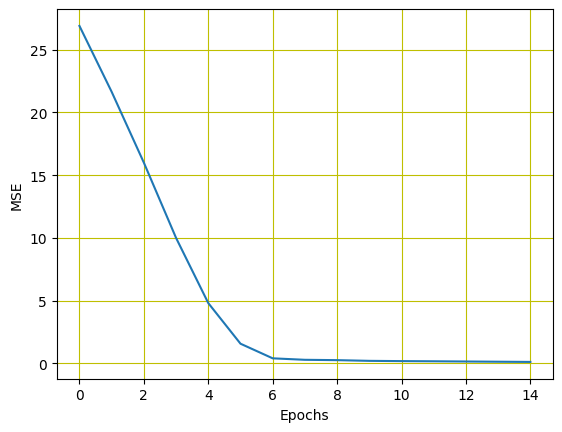

In [25]:
plt.plot(loss_arr)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.grid('True', color = 'y')
plt.show()

<h1> 2> Binary cross entropy already done before in DNN and SNN networks</h1>

<h1> 3> Multi Class Classification <h1>

Here we assume that our model ouputs a categorical distribution as output, which contains probability that a particular training example belongs to a particular class. To make sure that all the probabilities sum to 1, we use softmax layer at the end, which makes sure all outputs add up to 1. Basically, we want to maximize the probability that given a training example x, it belongs to the correct y class.
<br><br>
$\hat{\phi} = \underset{\phi}{\operatorname{argmax}}[ P_r(y=k|x)] = softmax_k(f[x;\phi])$


In [29]:
from sklearn.datasets import load_iris

In [39]:
def gen_multi_data():
  iris = load_iris()
  X = iris.data
  Y = iris.target
  X = torch.tensor(X, dtype = torch.float32)
  Y = torch.tensor(Y, dtype = torch.long)

  return [X, Y]


In [40]:
X, Y = gen_multi_data()

In [41]:
class MCC(nn.Module):
  def __init__(self):
    super().__init__()
    self.hidden1 = nn.Linear(4, 128)
    self.act1 = nn.ReLU()
    self.hidden2  = nn.Linear(128, 64)
    self.act2= nn.ReLU()
    self.output = nn.Linear(64, 3)

  def forward(self, x):
    x = self.act1(self.hidden1(x))
    x = self.act2(self.hidden2(x))
    x = self.output(x)

    return x


In [42]:
model = MCC()
print(model)

MCC(
  (hidden1): Linear(in_features=4, out_features=128, bias=True)
  (act1): ReLU()
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (act2): ReLU()
  (output): Linear(in_features=64, out_features=3, bias=True)
)


In [43]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [44]:
n_epochs = 15
loss_arr = []
batch_size = 10
verbose = False

for epoch in range(n_epochs):
  loss_batch = []
  for i in range(0, len(X), batch_size):
    X_batch = X[i:i+batch_size]
    Y_batch = Y[i:i+batch_size]
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, Y_batch)
    loss_batch.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  if verbose:
    print(f'Epoch {epoch} loss: {np.mean(loss_batch)}')

  loss_arr.append(np.mean(loss_batch))


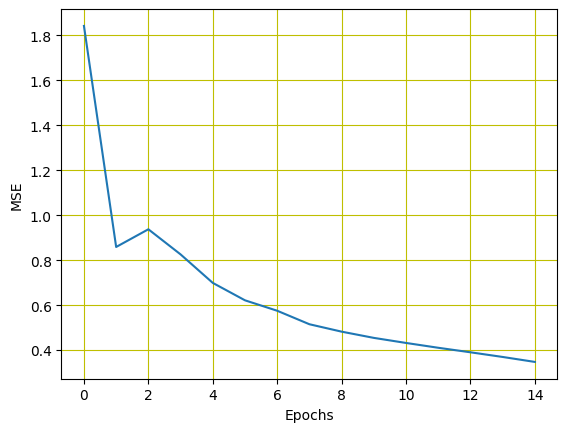

In [45]:
plt.plot(loss_arr)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.grid('True', color = 'y')
plt.show()

In [49]:
y_pred = model(X)
predicted_classes = torch.argmax(y_pred, axis = 1)
correct = (predicted_classes == Y).sum().item()
total = Y.size(0)
accuracy = correct/total
print(f'Accuracy score {accuracy}')

Accuracy score 0.98


<h1>4> Multiheaded Network</h1>
We want to to maximize probabilities for all different heads we have in the network given an x

In [61]:
def create_multi_head_data(N=200):
  X = np.random.randn(N, 5).astype(np.float32)

  # Regression
  y_reg = (X[:,0]*2 - X[:,1]*1 + np.random.randn(N)*0.1).astype(np.float32)
  y_reg = y_reg.reshape(-1,1)

  # Multiclass classification
  y_clf = np.random.randint(0,3,size=N).astype(np.int64)

  # Binary classification target
  y_bin = ((X[:,2] + X[:,3])>0).astype(np.int64)

  # Convert to tensors
  X = torch.tensor(X)
  y_reg = torch.tensor(y_reg, dtype = torch.float32)
  y_clf = torch.tensor(y_clf, dtype = torch.long)
  y_bin = torch.tensor(y_bin, dtype = torch.float32).view(-1, 1)

  return [X, y_reg, y_clf, y_bin]

In [62]:
X, y_reg, y_clf, y_bin = create_multi_head_data(300)

In [83]:
class MultiHead(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.shared = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU()
    )

    #regression head
    self.reg_head = nn.Linear(64, 1)
    #multiclass head
    self.clf_head = nn.Linear(64, 3)
    #binary head
    self.bin_head = nn.Linear(64, 1)

  def forward(self, x):
    x = self.shared(x)
    reg_out = self.reg_head(x)
    clf_out = self.clf_head(x)
    bin_out = nn.Sigmoid()(self.bin_head(x))

    return reg_out, clf_out, bin_out

In [84]:
model = MultiHead(5)
print(model)

MultiHead(
  (shared): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (reg_head): Linear(in_features=64, out_features=1, bias=True)
  (clf_head): Linear(in_features=64, out_features=3, bias=True)
  (bin_head): Linear(in_features=64, out_features=1, bias=True)
)


In [85]:
loss_reg = nn.MSELoss()
loss_clf = nn.CrossEntropyLoss()
loss_bin = nn.BCELoss()

In [102]:
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [103]:
n_epochs = 50
loss_arr_clf = []
loss_arr_reg = []
loss_arr_bin = []
loss_total = []
batch_size = 10
verbose = False

for epoch in range(n_epochs):
  loss_batch = []
  loss_total_batch = []
  for i in range(0, len(X), batch_size):
    X_batch = X[i:i+batch_size]
    #different head batches
    y_reg_batch = y_reg[i:i+batch_size]
    y_clf_batch = y_clf[i:i+batch_size]
    y_bin_batch = y_bin[i:i+batch_size]
    #prediction for different heads
    reg_out, clf_out, bin_out = model(X_batch)
    #calc the individual losses
    reg_loss = loss_reg(reg_out, y_reg_batch)
    clf_loss = loss_clf(clf_out, y_clf_batch)
    bin_loss = loss_bin(bin_out, y_bin_batch)
    loss = reg_loss + clf_loss + bin_loss
    #store losses
    loss_batch.append([reg_loss.item(), clf_loss.item(), bin_loss.item()])
    loss_total_batch.append(loss.item())
    #backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  if verbose:
    print(f'Epoch {epoch} loss: {np.mean(loss_total_batch)}')

  loss_total.append(np.mean(loss_total_batch))
  loss_batch = np.array(loss_batch)
  loss_arr_reg.append(np.mean(loss_batch[:,0], axis = 0))
  loss_arr_clf.append(np.mean(loss_batch[:,1], axis = 0))
  loss_arr_bin.append(np.mean(loss_batch[:,2], axis = 0))


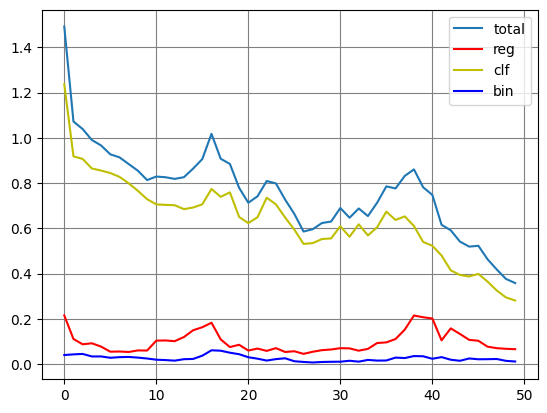

In [108]:
plt.plot(loss_total, label = 'total')
plt.plot(loss_arr_reg, 'r', label = "reg")
plt.plot(loss_arr_clf, 'y', label = 'clf')
plt.plot(loss_arr_bin, 'b', label = 'bin')
plt.grid('True', color = 'gray')
plt.legend()
plt.show()

In [109]:
model.eval()
with torch.no_grad():
    reg_out, clf_out, bin_out = model(X)

    # Regression MSE
    mse = ((reg_out - y_reg)**2).mean().item()

    # Multiclass accuracy
    clf_pred = torch.argmax(clf_out, dim=1)
    clf_acc = (clf_pred == y_clf).float().mean().item()

    # Binary accuracy
    bin_acc = (bin_out.round() == y_bin).float().mean().item()

print(f"Regression MSE: {mse:.4f}, Multiclass Acc: {clf_acc:.4f}, Binary Acc: {bin_acc:.4f}")

Regression MSE: 0.0801, Multiclass Acc: 0.9300, Binary Acc: 1.0000
